**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

*   NOMBRE: Gabriela
*   MATRÍCULA: A01753492

En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [41]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [43]:
#Descarga el archivo: computer_prices.csv y guarda, en un dataframe (compu_df), todos sus registros.
ruta_archivo = "/content/drive/MyDrive/Colab Notebooks/Maestria en IA/Ciencia de datos enero 2026/automobile_dataset.csv"
cars_df = pd.read_csv(ruta_archivo)

In [44]:
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

Son 11 columnas numericas y 15 columnas de texto

In [45]:
# Buscar en qué columnas aparece el símbolo '?'
columnas_con_simbolo = [col for col in cars_df.columns if (cars_df[col] == '?').any()]
columnas_con_simbolo

['normalized_losses', 'bore', 'stroke', 'horsepower', 'peak_rpm', 'price']

In [46]:
# Reemplazar '?' por NaN y limpiar
cars_df.replace('?', np.nan, inplace=True)

# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

In [47]:
# Duplicados y faltantes
print(f"Duplicados: {cars_df.duplicated().sum()}")
print(f"Faltantes:\n{cars_df.isnull().sum()}")

Duplicados: 0
Faltantes:
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             0
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


In [48]:
# Calcular la cantidad de nulos y el porcentaje
missing_count = cars_df.isnull().sum()
missing_percentage = (cars_df.isnull().sum() / len(cars_df)) * 100

# Crear un dataframe para visualizarlo mejor
df_missing = pd.DataFrame({
    'Valores Faltantes': missing_count,
    'Porcentaje (%)': missing_percentage
})

# Mostrar solo las columnas que tienen faltantes
print(df_missing[df_missing['Valores Faltantes'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

                   Valores Faltantes  Porcentaje (%)
normalized_losses                 41        20.00000
bore                               4         1.95122
stroke                             4         1.95122
price                              4         1.95122
horsepower                         2         0.97561
peak_rpm                           2         0.97561


In [49]:
#  NUMÉRICAS -
 #Guardar el resumen básico (media, min, max, etc.)

cars_df['horsepower'] = pd.to_numeric(cars_df['horsepower'])
# Ahora, cuando separes las numéricas de nuevo, ya aparecerá
df_num = cars_df.select_dtypes(include=[np.number])
resumen_num = cars_df.select_dtypes(include='number').describe()

# Agregar las filas de sesgo (skew) y curtosis (kurt)
resumen_num.loc['skew'] = cars_df.select_dtypes(include='number').skew()
resumen_num.loc['kurt'] = cars_df.select_dtypes(include='number').kurt()

resumen_num

,symboling,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,compression_ratio,horsepower,city_mpg,highway_mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,203.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,4.380488,126.907317,10.142537,104.256158,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,1.080854,41.642693,3.972040,39.714369,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,2.000000,61.000000,7.000000,48.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,4.000000,97.000000,8.600000,70.000000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,4.000000,120.000000,9.000000,95.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,4.000000,141.000000,9.400000,116.000000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,12.000000,326.000000,23.000000,288.000000,49.000000,54.000000
skew,0.211072,1.050214,0.155954,0.904003,0.063123,0.681398,2.817459,1.947655,2.610862,1.391029,0.663704,0.539997
kurt,-0.676271,1.017039,-0.082895,0.702764,-0.443812,-0.042854,13.714866,5.305682,5.233054,2.623280,0.578648,0.440070


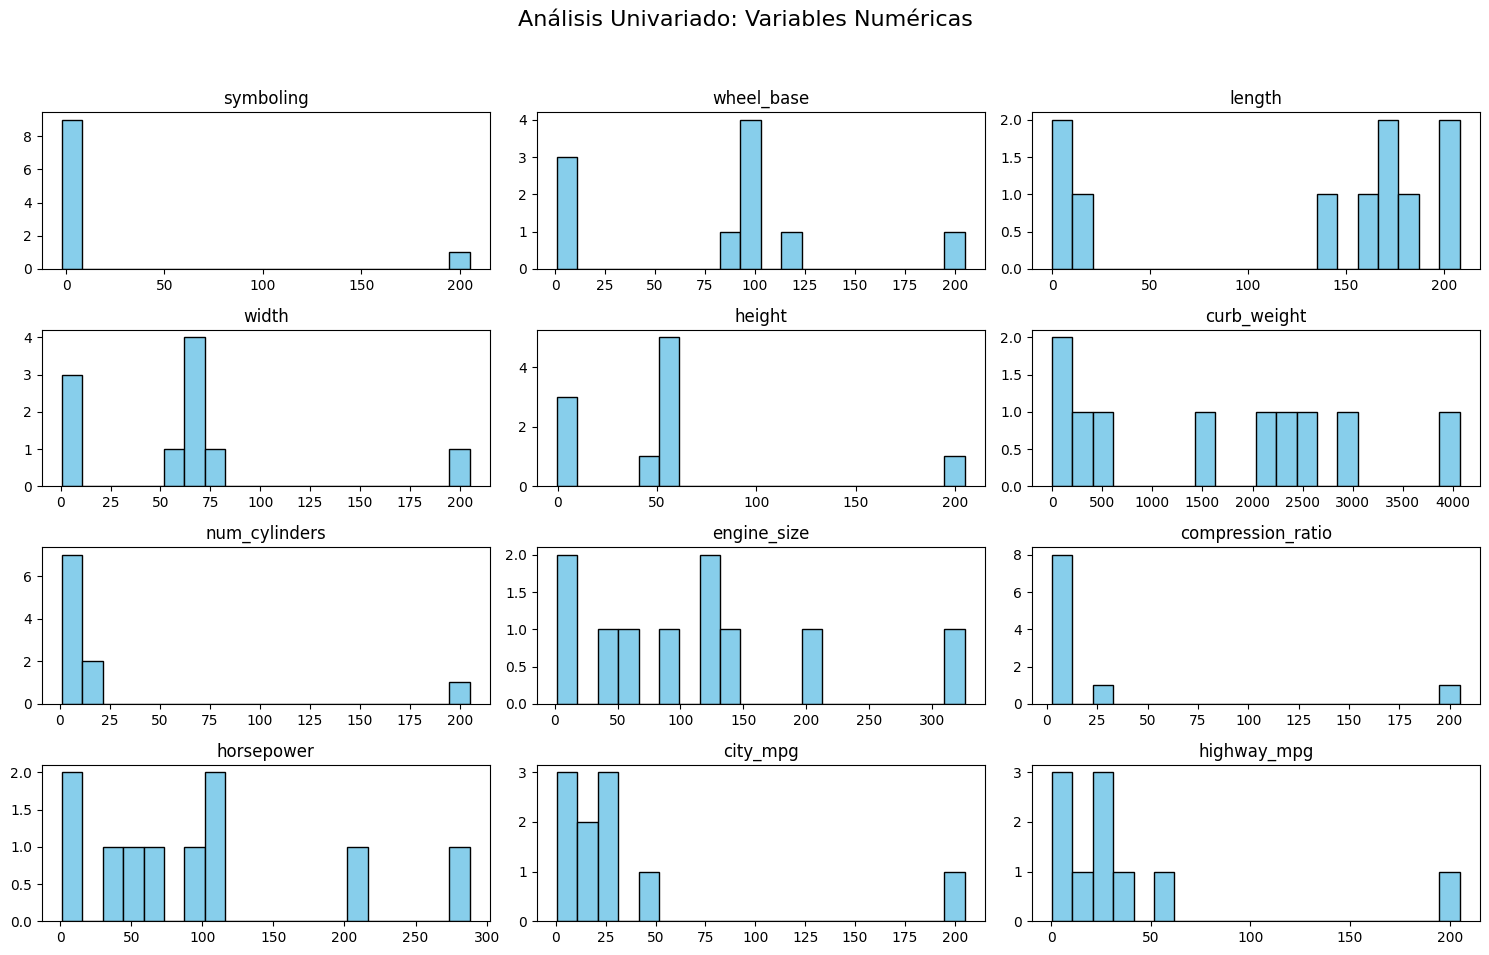

In [50]:
# Generar Histogramas
resumen_num.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black', grid=False)
plt.suptitle("Análisis Univariado: Variables Numéricas", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [51]:
# Resumen estadístico de categoricas (cantidad, únicos, el que más se repite y su frecuencia)
cars_df.select_dtypes(include='object').describe()
cars_df

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.4,23.0,106.0,4800,26,27,22470


In [52]:
# Tablas de frecuencia]
for col in cars_df.select_dtypes(include='object').columns:
    # Mostramos el nombre de la columna y su Top 10
    display(cars_df[col].value_counts().head(10).to_frame())

,count
normalized_losses,
161,11
91,8
150,7
128,6
104,6
134,6
74,5
103,5
168,5


,count
make,
toyota,32
nissan,18
mazda,17
mitsubishi,13
honda,13
subaru,12
volkswagen,12
volvo,11
peugot,11


,count
fuel_type,
gas,185
diesel,20


,count
aspiration,
std,168
turbo,37


,count
num_doors,
four,116
two,89


...

,count
fuel_system,
mpfi,94
2bbl,66
idi,20
1bbl,11
spdi,9
4bbl,3
mfi,1
spfi,1


,count
bore,
3.62,23
3.19,20
3.15,15
2.97,12
3.03,12
3.46,9
3.31,8
3.43,8
3.78,8


,count
stroke,
3.4,20
3.15,14
3.23,14
3.03,14
3.39,13
2.64,11
3.29,9
3.35,9
3.46,8


,count
peak_rpm,
5500,37
4800,36
5000,27
5200,23
5400,13
6000,9
5800,7
4500,7
5250,7


,count
price,
16500,2
6229,2
7609,2
7957,2
6692,2
5572,2
8495,2
8845,2
7295,2


# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

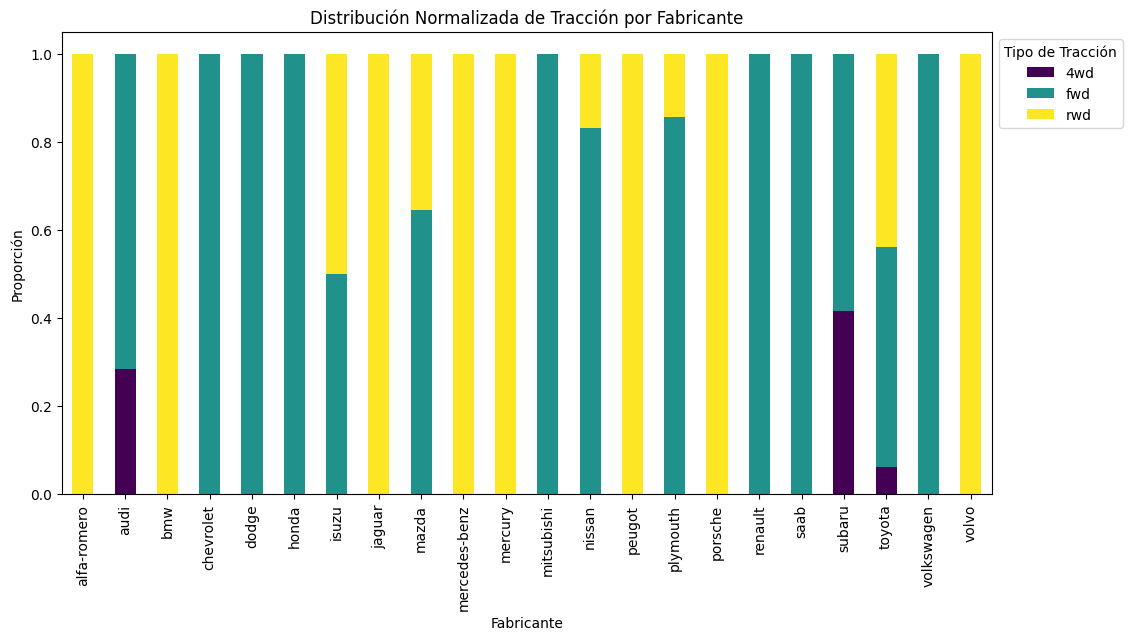

In [53]:
# Gráfico de barras apiladas normalizadas
traccion_make = pd.crosstab(cars_df['make'], cars_df['drive_wheels'], normalize='index')
traccion_make.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Distribución Normalizada de Tracción por Fabricante')
plt.xlabel('Fabricante')
plt.ylabel('Proporción')
plt.legend(title='Tipo de Tracción', bbox_to_anchor=(1, 1))
plt.show()

/tmp/ipython-input-255/3844675406.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='body_style', y='price', data=cars_df, palette='Set2')


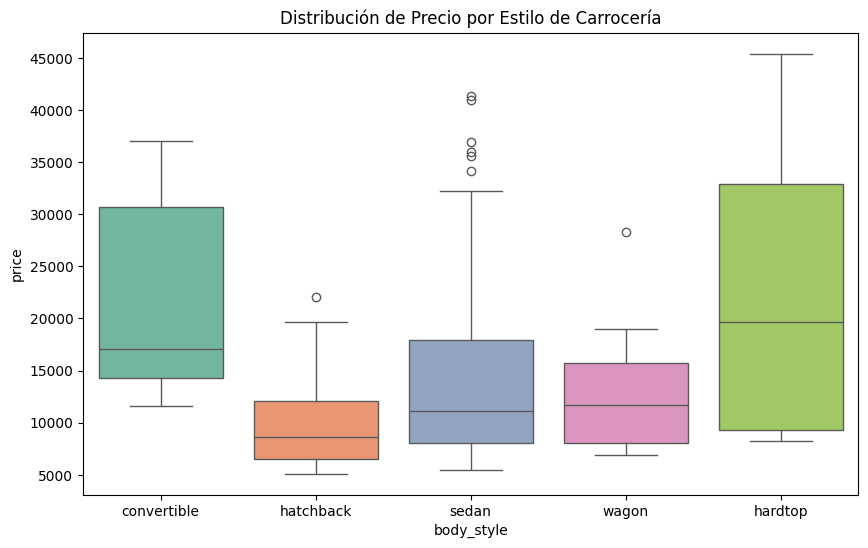

In [54]:
# Convertir el precio a número (float)
cars_df['price'] = pd.to_numeric(cars_df['price'], errors='coerce')

# box plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='body_style', y='price', data=cars_df, palette='Set2')
plt.title('Distribución de Precio por Estilo de Carrocería')
plt.show()

/tmp/ipython-input-255/1056491526.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='price', y='make', data=top_10_caros, palette='magma')


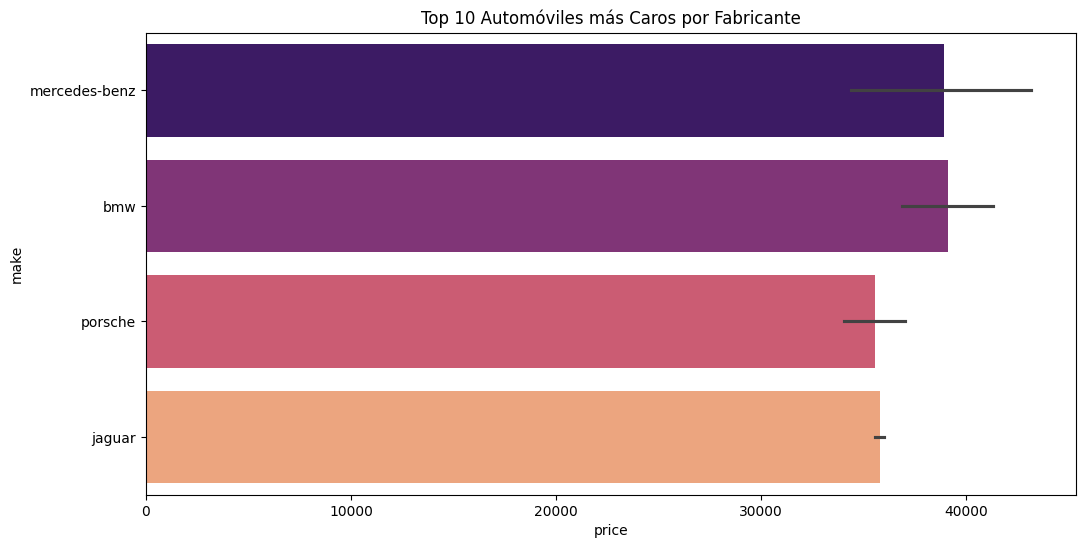

In [55]:
# Obtenemos los 10 más caros (usamos el índice para no perder el fabricante)
top_10_caros = cars_df.nlargest(10, 'price')

plt.figure(figsize=(12, 6))
sns.barplot(x='price', y='make', data=top_10_caros, palette='magma')
plt.title('Top 10 Automóviles más Caros por Fabricante')
plt.show()

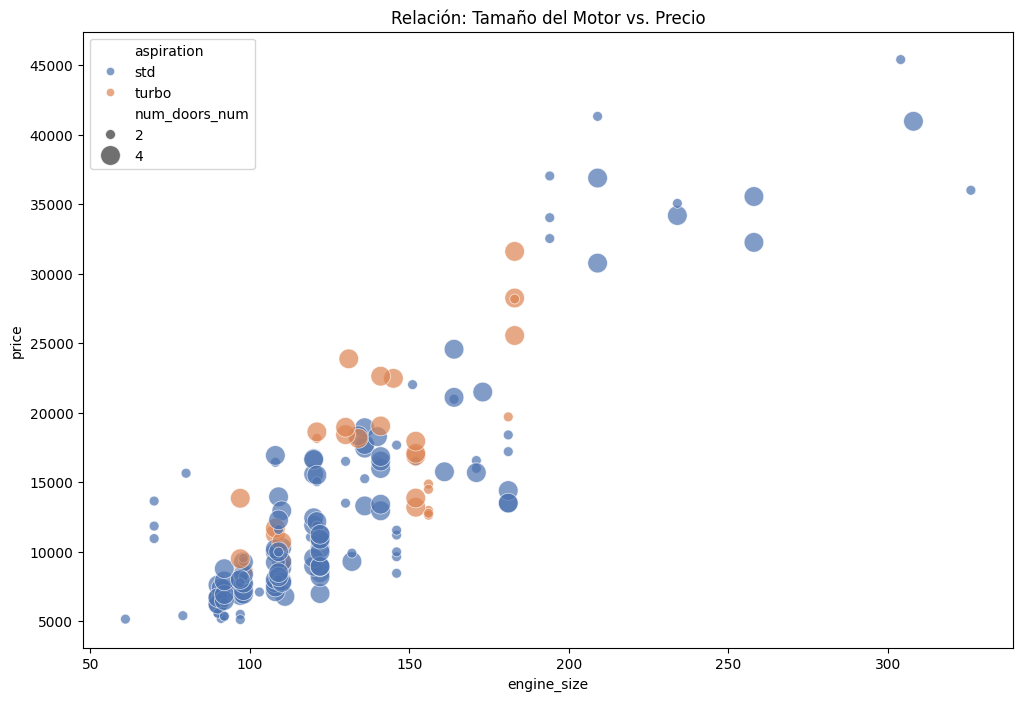

In [56]:
# num_doors debe ser numérico para que el tamaño (s) funcione bien
temp_df = cars_df.copy()
temp_df['num_doors_num'] = temp_df['num_doors'].map({'two': 2, 'four': 4})

plt.figure(figsize=(12, 8))
sns.scatterplot(data=temp_df, x='engine_size', y='price',
                hue='aspiration', size='num_doors_num',
                sizes=(50, 200), alpha=0.7, palette='deep')
plt.title('Relación: Tamaño del Motor vs. Precio')
plt.show()

4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

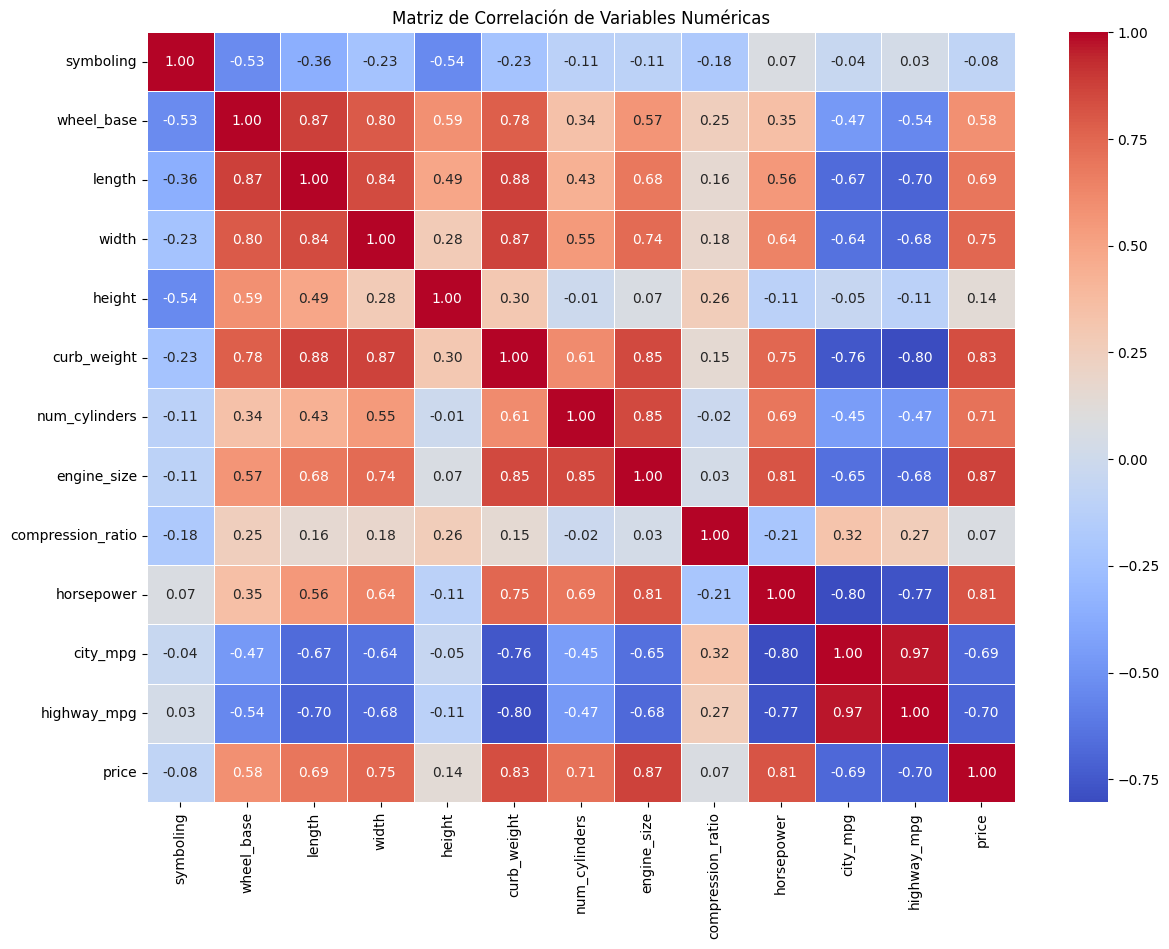

In [57]:
# Filtrar solo las variables numéricas para la correlación
matriz_corr = cars_df.corr(numeric_only=True)

# Dibujar el mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

las tres variables que más influyen en que un coche sea caro son:

engine_size (0.87): El tamaño del motor es el factor número uno. A motor más grande, precio mucho más alto.

curb_weight (0.83): El peso del automóvil (sin pasajeros) tiene una relación altísima con el costo.

horsepower (0.81): Los caballos de fuerza cierran el podio. Más potencia suele significar un precio mayor.

En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

# Ingeniería de características

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

In [60]:
# Definir la variable objetivo (y)
y = cars_df['price']

# Crear solo con las columnas numéricas que NO sean el precio
X = df_num[[col for col in df_num.columns if col != 'price']]

# --- INGENIERÍA DE CARACTERÍSTICAS ---

# Aplicar SimpleImputer (Estrategia: Mediana)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

In [61]:
# Escalar los valores de X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ¿Cuántos componentes se generarán?
print(f"Al aplicar PCA se generarán {X.shape[1]} componentes principales.")

Al aplicar PCA se generarán 12 componentes principales.


6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

In [62]:
# Aplicar PCA a los datos que ya escalamos (X_scaled)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Asignar nombres descriptivos (PC1, PC2, PC3...)
# Crear una lista dinámica basada en el número de columnas de X
nombres_pcs = [f'PC{i+1}' for i in range(X_pca.shape[1])]

# Crear el DataFrame resultante
df_pca = pd.DataFrame(data=X_pca, columns=nombres_pcs)

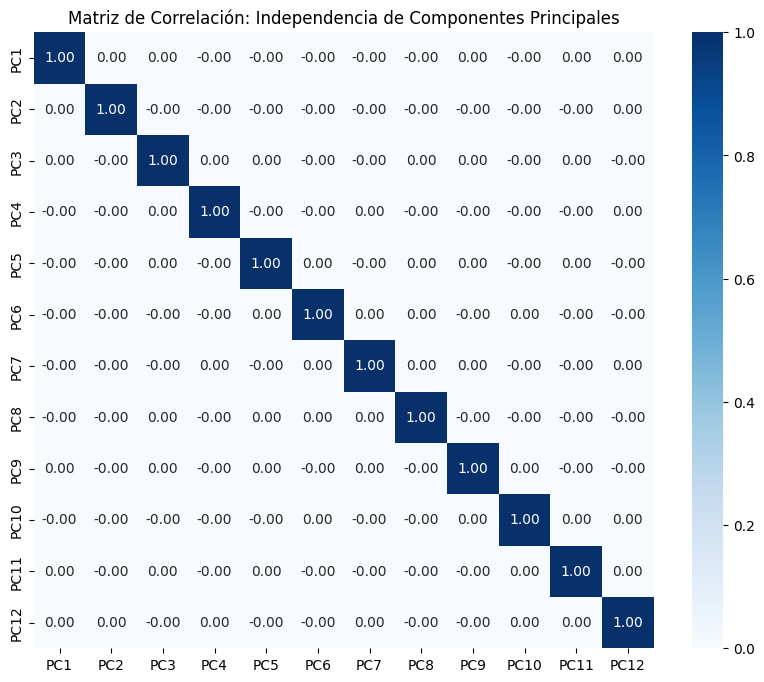

In [63]:
# Calcular la matriz de correlación de los componentes
corr_pca = df_pca.corr()

# Generar el mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pca, annot=True, cmap='Blues', fmt=".2f", cbar=True)
plt.title('Matriz de Correlación: Independencia de Componentes Principales')
plt.show()

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

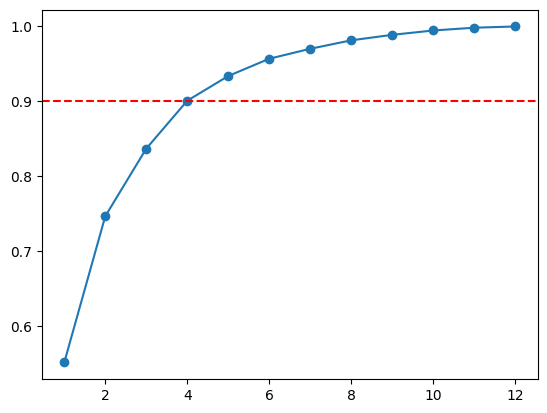

In [65]:
# Sumar la información (Varianza Acumulada)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

# Hacer la curva para ver el cruce
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--') # La meta es llegar a esta línea
plt.show()

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

In [66]:
# Extraer los pesos (loadings) del primer componente (PC1)
pesos_pc1 = pd.Series(pca.components_[0], index=X.columns)

#Imprimir la información de forma ordenada
print("Pesos de las variables originales en el PC1:")
print(pesos_pc1.sort_values(ascending=False))

Pesos de las variables originales en el PC1:
curb_weight          0.374480
length               0.348541
width                0.347320
engine_size          0.342131
horsepower           0.313450
wheel_base           0.307199
num_cylinders        0.264965
height               0.116350
compression_ratio    0.008488
symboling           -0.100283
city_mpg            -0.321085
highway_mpg         -0.333180
dtype: float64


9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [68]:
# Volver a identificar las columnas tipo 'object'
df_cat = cars_df.select_dtypes(include=['object'])

# Ahora aplicar el One-Hot Encoding
# drop_first=True quita la primera columna de cada categoría para evitar la redundancia
df_cat_encoded = pd.get_dummies(df_cat, drop_first=True)

# Verificar que ahora son números (0 y 1)
df_cat_encoded.head()

,normalized_losses_102,normalized_losses_103,normalized_losses_104,normalized_losses_106,normalized_losses_107,normalized_losses_108,normalized_losses_110,normalized_losses_113,normalized_losses_115,normalized_losses_118,...,peak_rpm_5250,peak_rpm_5300,peak_rpm_5400,peak_rpm_5500,peak_rpm_5600,peak_rpm_5750,peak_rpm_5800,peak_rpm_5900,peak_rpm_6000,peak_rpm_6600
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [69]:
# Basado en  gráfica del paso 7:
n_componentes_90 = 4

# Seleccionar esos 4 PCs
df_pca_seleccionados = df_pca.iloc[:, :n_componentes_90]

# Conjuntar todo (PCA + Categorías + Precio)
df_resultado_final = pd.concat([
    df_pca_seleccionados.reset_index(drop=True),
    df_cat_encoded.reset_index(drop=True),
    y.reset_index(drop=True)
], axis=1)

# Guardar el archivo
df_resultado_final.to_csv('dataset_final_autos_reducido.csv', index=False)